# ANÁLISIS EXPLORATORIO DE DATOS

In [2]:
import kagglehub
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

c:\Users\Usuario\miniconda3\envs\env_commerce_py313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Definición del problema
> - Recopilar los datos de ventas para visualizar compradores en potencia y los productos que mejor se venden y el numéro de ingresos anuales.
> ¿Que intervalo de facturación habrá para el siguiente año?

## Recopilación de datos

In [3]:
# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Usuario\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2


In [4]:
df_customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
df_geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
df_order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
df_order_payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
df_order_reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
df_orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
df_products = pd.read_csv("../data/raw/olist_products_dataset.csv")
df_sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
df_product_category_name_translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

In [5]:
df_orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [6]:
df_customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [7]:
# Unir Órdenes con Clientes
df_master = pd.merge(df_orders, df_customers, on="customer_id", how="left")

In [8]:
df_order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [9]:
# Unir con los Ítems 
df_master = pd.merge(df_master, df_order_items, on="order_id", how="left")

In [10]:
df_products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')

In [11]:
# Unir con Productos
df_master = pd.merge(df_master, df_products, on="product_id", how="left")

# Traducir las categorías (Para que sea legible)
df_master = pd.merge(df_master, df_product_category_name_translation, on="product_category_name", how="left")

In [12]:
df_order_payments.head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


In [13]:
df_master = pd.merge(df_master, df_order_payments[["order_id", "payment_value"]], on="order_id", how="left")

In [14]:
df_master.head(15)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,179.12
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,72.20
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,28.62
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,...,automotivo,49.0,608.0,1.0,7150.0,65.0,10.0,65.0,auto,175.26
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,36edbb3fb164b1f16485364b6fb04c73,98900,...,NaN,NaN,NaN,NaN,600.0,35.0,35.0,15.0,NaN,65.95
9,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,932afa1e708222e5821dac9cd5db4cae,26525,...,automotivo,59.0,956.0,1.0,50.0,16.0,16.0,17.0,auto,75.16


## Análisis descriptivo

In [15]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  str    
 1   customer_id                    118434 non-null  str    
 2   order_status                   118434 non-null  str    
 3   order_purchase_timestamp       118434 non-null  str    
 4   order_approved_at              118258 non-null  str    
 5   order_delivered_carrier_date   116360 non-null  str    
 6   order_delivered_customer_date  115037 non-null  str    
 7   order_estimated_delivery_date  118434 non-null  str    
 8   customer_unique_id             118434 non-null  str    
 9   customer_zip_code_prefix       118434 non-null  int64  
 10  customer_city                  118434 non-null  str    
 11  customer_state                 118434 non-null  str    
 12  order_item_id                  117604 non

In [16]:
df_master.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 176
order_delivered_carrier_date     2074
order_delivered_customer_date    3397
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     830
product_id                        830
seller_id                         830
shipping_limit_date               830
price                             830
freight_value                     830
product_category_name            2528
product_name_lenght              2528
product_description_lenght       2528
product_photos_qty               2528
product_weight_g                  850
product_length_cm                 850
product_height_cm                 850
product_width_cm                  850
product_cate

## Limpieza de datos

In [17]:
df_master.duplicated().sum()

np.int64(705)

In [18]:
df_master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'payment_value'],
      dtype='str')

In [19]:
df_master.drop(["order_status", "order_approved_at", "order_delivered_carrier_date", "order_estimated_delivery_date", "customer_zip_code_prefix", "customer_city",
                "customer_state", "seller_id", "shipping_limit_date", "freight_value", "product_category_name", "product_name_lenght", 
                "product_description_lenght", "product_photos_qty", "product_weight_g", "product_length_cm", "product_height_cm",
                "product_width_cm", "order_delivered_customer_date", "price", "product_id"], axis=1, inplace=True)

In [20]:
df_master.columns

Index(['order_id', 'customer_id', 'order_purchase_timestamp',
       'customer_unique_id', 'order_item_id', 'product_category_name_english',
       'payment_value'],
      dtype='str')

In [21]:
df_master

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,order_item_id,product_category_name_english,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,1.0,perfumery,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,1.0,auto,179.12
...,...,...,...,...,...,...,...
118429,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,da62f9e57a76d978d02ab5362c509660,1.0,baby,195.00
118430,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,737520a9aad80b3fbbdad19b66b37b30,1.0,home_appliances_2,271.01
118431,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,5097a5312c8b157bb7be58ae360ef43c,1.0,computers_accessories,441.16
118432,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,5097a5312c8b157bb7be58ae360ef43c,2.0,computers_accessories,441.16


## Análisis de las variables

### Análisis univariante de variables.

In [22]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  str    
 1   customer_id                    118434 non-null  str    
 2   order_purchase_timestamp       118434 non-null  str    
 3   customer_unique_id             118434 non-null  str    
 4   order_item_id                  117604 non-null  float64
 5   product_category_name_english  115881 non-null  str    
 6   payment_value                  118431 non-null  float64
dtypes: float64(2), str(5)
memory usage: 6.3 MB


#### Análisis de la variable `order_id`

In [23]:
df_master["order_id"].value_counts()

order_id
895ab968e7bb0d5659d16cd74cd1650c    63
fedcd9f7ccdc8cba3a18defedd1a5547    38
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
a3725dfe487d359b5be08cac48b64ec5    24
                                    ..
880675dff2150932f1601e1c07eadeeb     1
9c5dedf39a927c1b2549525ed64a053c     1
63943bddc261676b46f01ca7ac2f7bd8     1
83c1379a015df1e13d02aae0204711ab     1
66dea50a8b16d9b4dee7af250b4be1a5     1
Name: count, Length: 99441, dtype: int64

In [24]:
df_master[df_master["order_id"] == "8272b63d03f5f79c56e9e4120aec44ef"].head(25)

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,order_item_id,product_category_name_english,payment_value
105654,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,1.0,health_beauty,196.11
105655,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,2.0,health_beauty,196.11
105656,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,3.0,health_beauty,196.11
105657,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,4.0,health_beauty,196.11
105658,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,5.0,health_beauty,196.11
105659,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,6.0,health_beauty,196.11
105660,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,7.0,health_beauty,196.11
105661,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,8.0,health_beauty,196.11
105662,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,9.0,health_beauty,196.11
105663,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2017-07-16 18:19:25,4546caea018ad8c692964e3382debd19,10.0,health_beauty,196.11


In [25]:
df_master[df_master["order_id"] == "8272b63d03f5f79c56e9e4120aec44ef"]["product_category_name_english"].value_counts()

product_category_name_english
health_beauty    21
Name: count, dtype: int64

In [26]:
# Sin duplicados en order_id para visualizar las compras reales.
df_master[~df_master.duplicated(subset=["order_id"])]

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,order_item_id,product_category_name_english,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,18.12
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,1.0,perfumery,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,1.0,auto,179.12
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,1.0,pet_shop,72.20
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,1.0,stationery,28.62
...,...,...,...,...,...,...,...
118428,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-09 09:54:05,6359f309b166b0196dbf7ad2ac62bb5a,1.0,health_beauty,85.08
118429,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,da62f9e57a76d978d02ab5362c509660,1.0,baby,195.00
118430,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,737520a9aad80b3fbbdad19b66b37b30,1.0,home_appliances_2,271.01
118431,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,5097a5312c8b157bb7be58ae360ef43c,1.0,computers_accessories,441.16


##### Observaciones:
> - `order_id`: Es la clave única que identifica cada orden. Hay un total de 99441 órdenes realizadas. Puede aparecer el mismo order_id múltiples veces puesto que se genera una fila para cada producto distinto dentro de la misma orden.

#### Análisis de la variable `customer_id`

In [27]:
df_master["customer_id"].value_counts()

customer_id
270c23a11d024a44c896d1894b261a83    63
13aa59158da63ba0e93ec6ac2c07aacb    38
9af2372a1e49340278e7c1ef8d749f34    29
92cd3ec6e2d643d4ebd0e3d6238f69e2    26
d22f25a9fadfb1abbc2e29395b1239f4    24
                                    ..
47cd45a6ac7b9fb16537df2ccffeb5ac     1
39bd1228ee8140590ac3aca26f2dfe00     1
1fca14ff2861355f6e5f14306ff977a7     1
1aa71eb042121263aafbe80c1b562c9c     1
edb027a75a1449115f6b43211ae02a24     1
Name: count, Length: 99441, dtype: int64

> - `customer_id`: Presenta los id únicos de las compras realizadas. Se puede observar que el id que tiene más registros suma 21, esto se debe a que los productos de su compra suman un total de 21 y se genera una fila nueva para cada producto.


#### Análsisi de la variable `order_purchase_timestamp`

In [28]:
# Se crea un dataframe sin repeticiones en los registros de `order_id`
df_unique_order = df_master.drop_duplicates("order_id")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_12996\921675424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_unique_order, y="order_purchase_timestamp", order=df_unique_order["order_purchase_timestamp"].value_counts().index[:20],


Text(0.5, 0, 'Número de ventas')

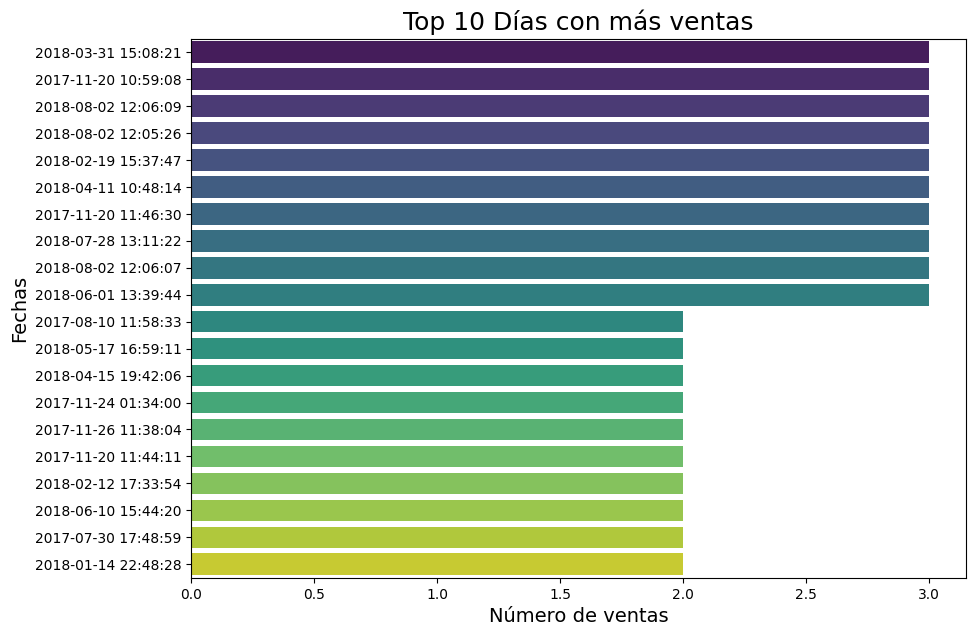

In [29]:
plt.figure(figsize=(10, 7))
sns.countplot(data=df_unique_order, y="order_purchase_timestamp", order=df_unique_order["order_purchase_timestamp"].value_counts().index[:20],
              palette="viridis")
plt.title("Top 10 Días con más ventas", fontsize=18)
plt.ylabel("Fechas", fontsize=14)
plt.xlabel("Número de ventas", fontsize=14)

##### Observaciones:
> - Se puede observar que la fecha con más ventas es el 2018-03-31 con más de 3 ventas. El 2018 ha producido las mejores ventas, contiene 8 de las fechas dentro del top 10. Los días con más ventas suelen ser los más próximos a la primera mitad del mes, excepto en épocas próximas a festividades donde el día con más ventas está cerca del final del mes.

#### Análisis de la variable `customer_unique_id`

In [30]:
df_unique_order["customer_unique_id"].value_counts()

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
                                    ..
6359f309b166b0196dbf7ad2ac62bb5a     1
da62f9e57a76d978d02ab5362c509660     1
737520a9aad80b3fbbdad19b66b37b30     1
5097a5312c8b157bb7be58ae360ef43c     1
60350aa974b26ff12caad89e55993bd6     1
Name: count, Length: 96096, dtype: int64

In [31]:
df_unique_order[df_unique_order["customer_unique_id"] =="8d50f5eadf50201ccdcedfb9e2ac8455"]

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,order_item_id,product_category_name_english,payment_value
2786,c2213109a2cc0e75d55585b7aaac6d97,897b7f72042714efaa64ac306ba0cafc,2018-08-07 23:32:14,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,sports_leisure,34.44
4299,23427a6bd9f8fd1b51f1b1e5cc186ab8,a8fabc805e9a10a3c93ae5bff642b86b,2018-05-21 22:44:31,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,sports_leisure,53.38
6069,e3071b7624445af6e4f3a1b23718667d,0bf8bf19944a7f8b40ba86fef778ca7c,2017-09-05 22:14:52,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,sports_leisure,51.75
13819,d3582fd5ccccd9cb229a63dfb417c86f,a682769c4bc10fc6ef2101337a6c83c9,2018-08-20 19:14:26,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,costruction_tools_tools,38.66
19227,5837a2c844decae8a778657425f6d664,31dd055624c66f291578297a551a6cdf,2017-07-17 22:11:13,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,NaN,25.59
22704,bf92c69b7cc70f7fc2c37de43e366173,42dbc1ad9d560637c9c4c1533746f86d,2017-07-24 22:11:50,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,sports_leisure,166.71
29613,6bdf325f0966e3056651285c0aed5aad,6289b75219d757a56c0cce8d9e427900,2018-05-22 23:08:55,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,sports_leisure,62.95
40229,4f62d593acae92cea3c5662c76122478,dfb941d6f7b02f57a44c3b7c3fefb44b,2017-07-18 23:10:58,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,fashion_bags_accessories,21.77
47032,b850a16d8faf65a74c51287ef34379ce,1bd3585471932167ab72a84955ebefea,2017-11-22 20:01:53,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,sports_leisure,21.77
69929,519203404f6116d406a970763ee75799,1c62b48fb34ee043310dcb233caabd2e,2017-08-05 08:59:43,8d50f5eadf50201ccdcedfb9e2ac8455,1.0,NaN,81.89


#### Observaciones:
> - `customer_unique_id`: Es la clave única del cliente, esta clave se repite en el dataframe por cada orden que se ha realizado.
> - El cliente recurrente que acumula más ordenes, ha realizado 17 ordenes distintas.

#### Análisis de la variable `product_category_name_english`

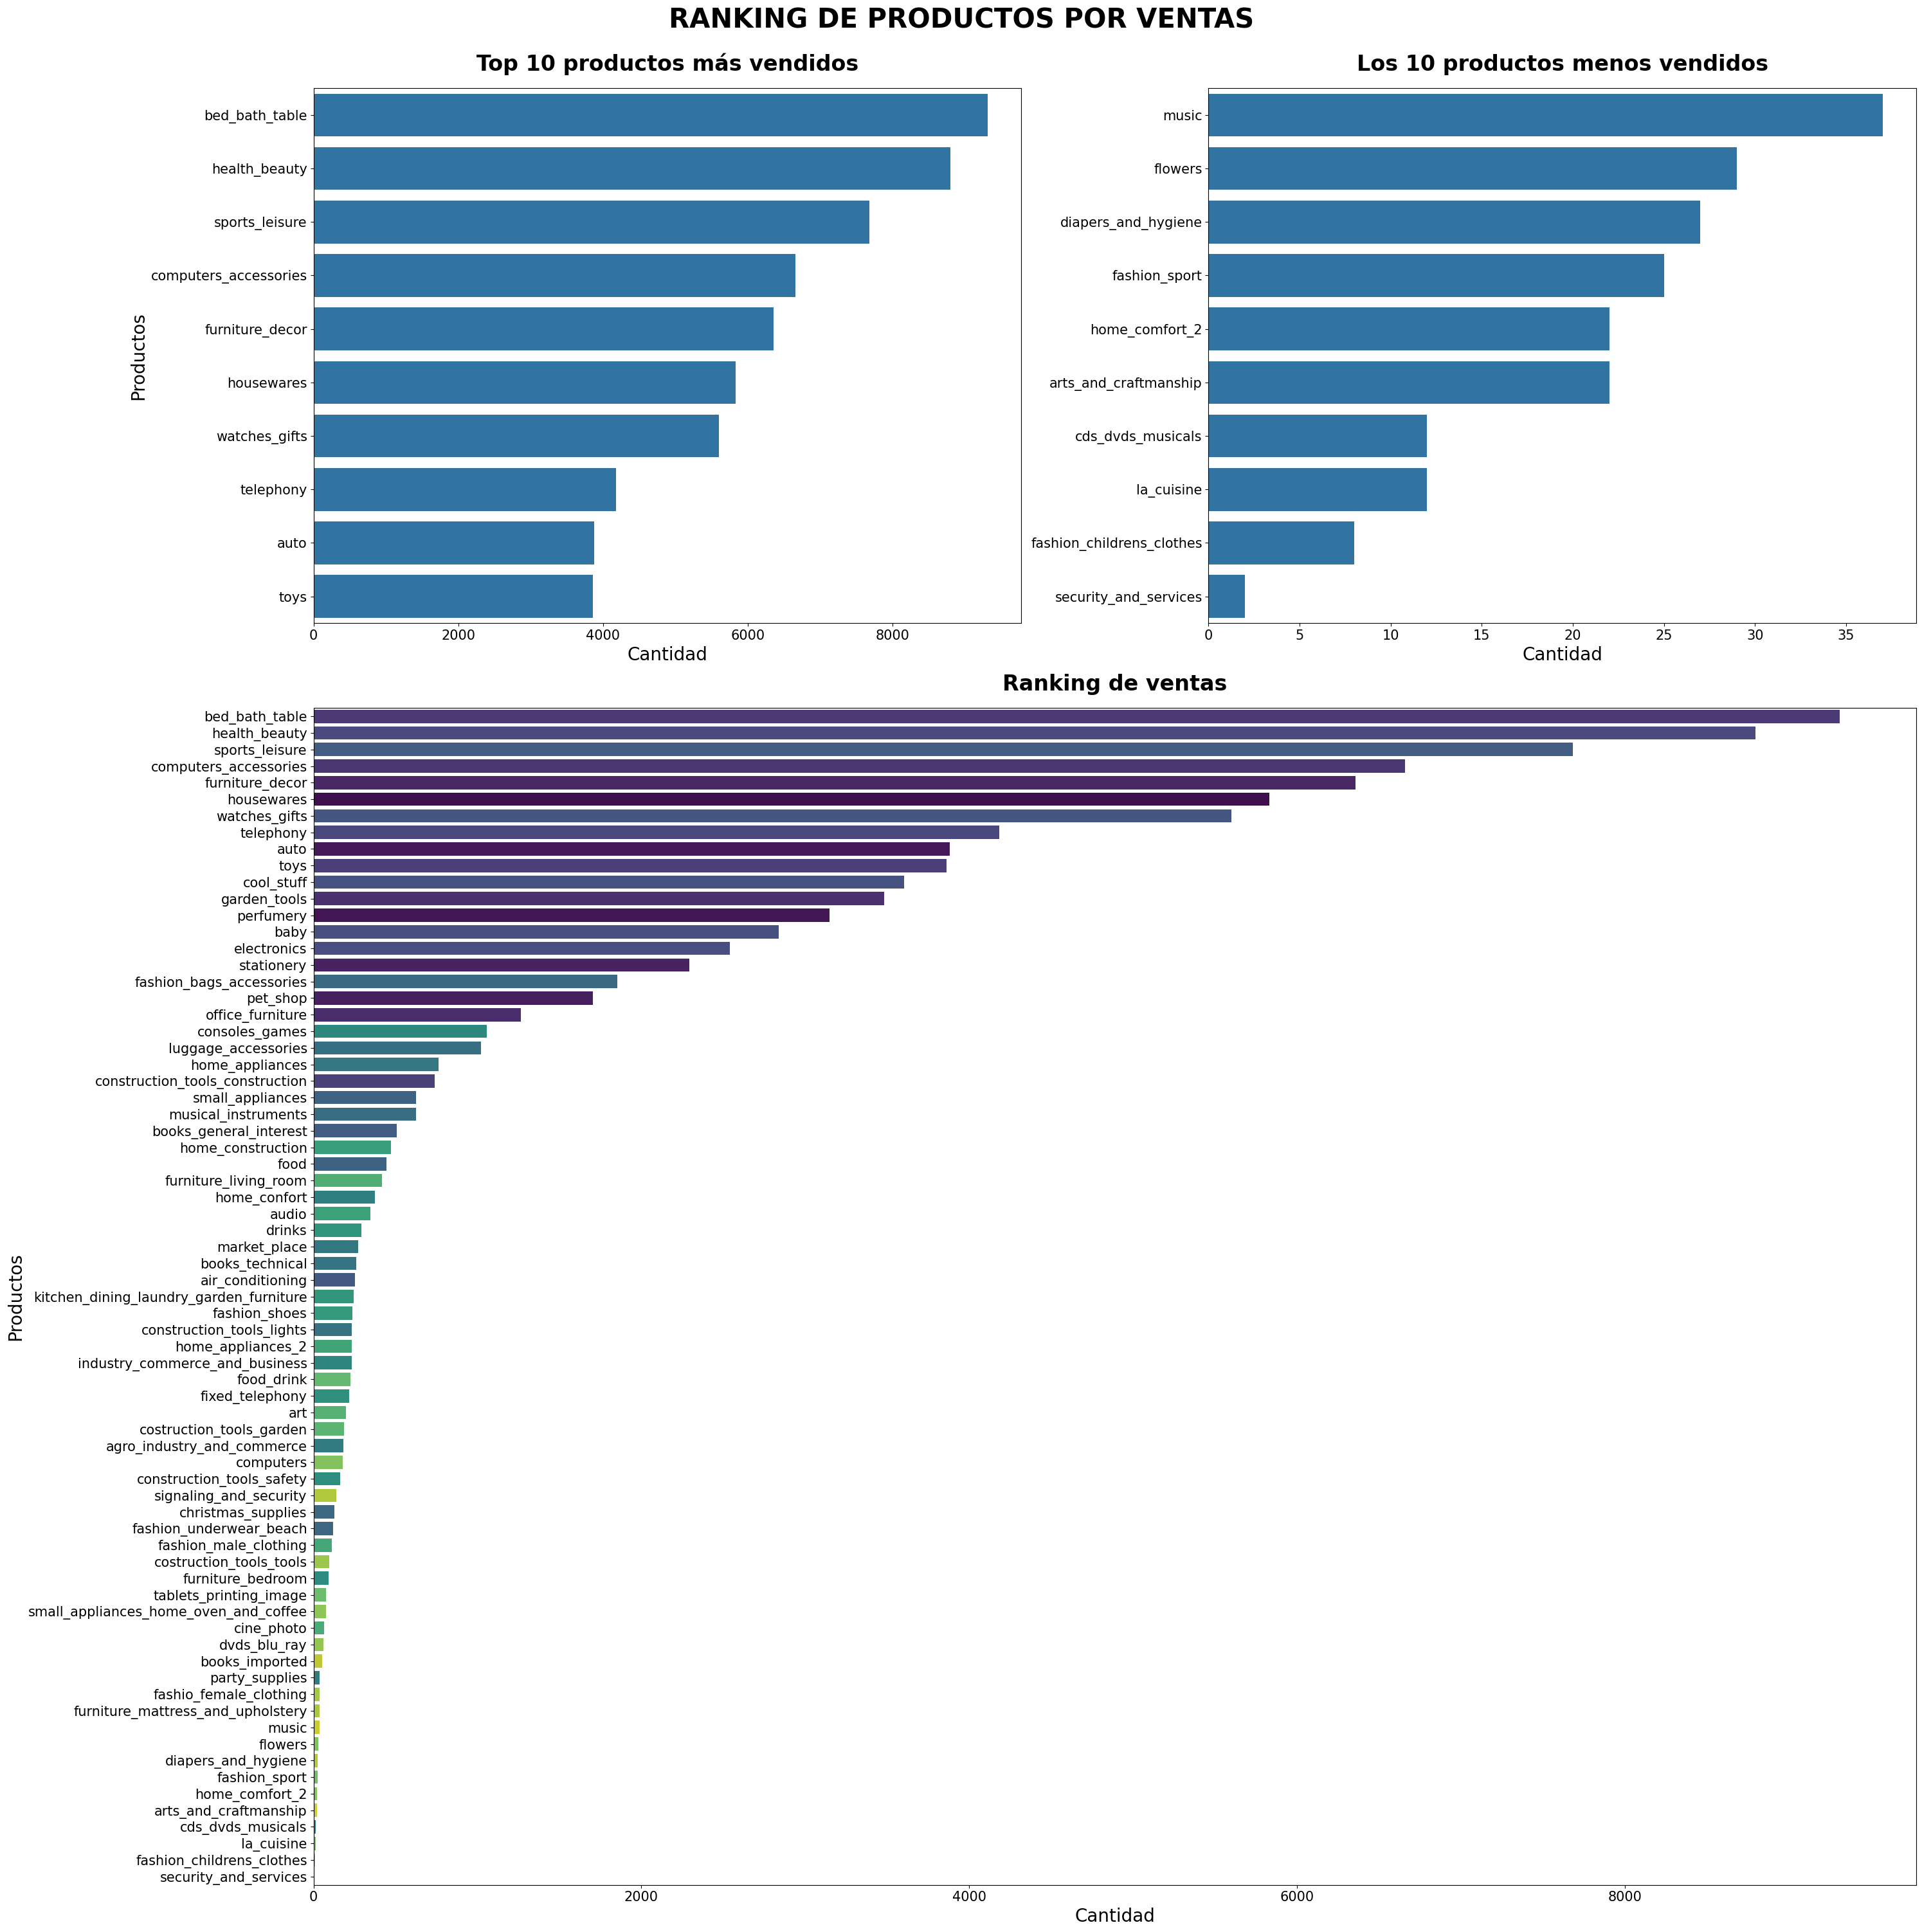

In [32]:
mosaic = [["A", "B"], 
          ["C", "C"]]

fig, axis = plt.subplot_mosaic(mosaic, figsize=(30,30), gridspec_kw={'height_ratios': [1, 2.20]})
fig.suptitle("RANKING DE PRODUCTOS POR VENTAS", fontsize=30, fontweight="bold", y=1)

sns.countplot(ax=axis["A"],data=df_unique_order, y="product_category_name_english", 
              order=df_unique_order["product_category_name_english"].value_counts().head(10).index)
axis["A"].set_title("Top 10 productos más vendidos", size=24, weight='bold', pad=20)
axis["A"].set_ylabel("Productos", size=20)
axis["A"].set_xlabel("Cantidad", size=20)
axis["A"].tick_params(labelsize=15)


sns.countplot(ax=axis["B"],data=df_unique_order, y="product_category_name_english", 
              order=df_unique_order["product_category_name_english"].value_counts().tail(10).index
              ).set(ylabel=None)
axis["B"].set_title("Los 10 productos menos vendidos", size=24, weight='bold', pad=20)
axis["B"].set_xlabel("Cantidad", size=20)
axis["B"].tick_params(labelsize=15)

sns.countplot(ax=axis["C"],data=df_unique_order, y="product_category_name_english", 
              order=df_unique_order["product_category_name_english"].value_counts().index,
              hue="product_category_name_english" ,palette="viridis", legend=False)
axis["C"].set_title("Ranking de ventas", size=24, weight='bold', pad=20)
axis["C"].set_ylabel("Productos", size=20)
axis["C"].set_xlabel("Cantidad", size=20)
axis["C"].tick_params(labelsize=15)

plt.tight_layout()


### Análisis de variables numéricas

#### Análisis de la variable `order_item_id`

In [33]:
df_master["order_item_id"].value_counts()

order_item_id
1.0     103057
2.0      10239
3.0       2376
4.0        986
5.0        469
6.0        262
7.0         60
8.0         36
9.0         28
10.0        25
11.0        17
12.0        13
13.0         8
14.0         7
15.0         5
16.0         3
17.0         3
18.0         3
19.0         3
20.0         3
21.0         1
Name: count, dtype: int64

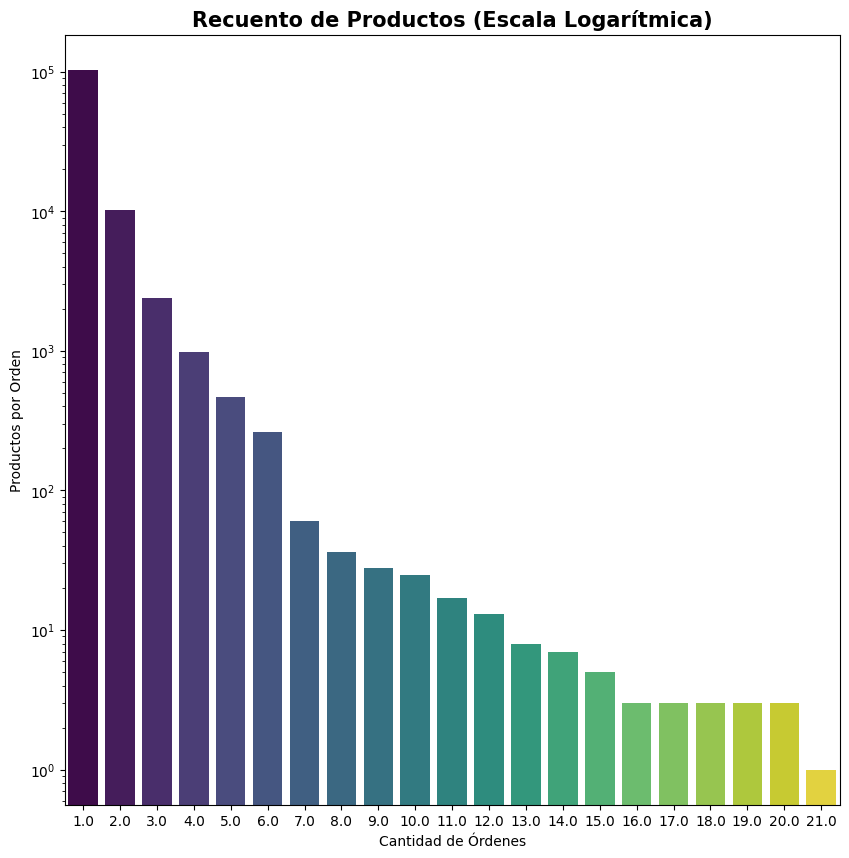

In [34]:
plt.figure(figsize=(10,10))

# Generamos la gráfica
ax = sns.countplot(data=df_master, x="order_item_id", hue="order_item_id", palette="viridis", legend=False)

# Aplicar escala logarítmica en el eje X (Cantidad)
ax.set_yscale("log")

plt.title("Recuento de Productos (Escala Logarítmica)", fontsize=15, fontweight='bold')
plt.xlabel("Cantidad de Órdenes")
plt.ylabel("Productos por Orden")

plt.show()

##### Observaciones:
> - `order_item_id`: Es una variable secuencial que enumera el registro de los productos comprados en una misma orden. Se han realizado 98666 compras de un solo producto y el máximo de productos que se ha registrado en una misma compra es de 21.
> -  La gráfica muestra una distribución con la moda muy marcada en el valor 1, decrece la frecuencia de forma exponencial a medida que aumenta el número de pedidos en una misma compra.

### Análisis de la variable `payment_value`

In [35]:
df_unique_order["payment_value"].sort_values(ascending=False)

15820    13664.08
79195     7274.88
26332     6929.31
33775     6922.21
4132      6726.66
           ...   
85285        0.01
1352         0.00
47586        0.00
47962        0.00
36657         NaN
Name: payment_value, Length: 99441, dtype: float64

In [36]:
df_unique_order["payment_value"].value_counts().head(10)

payment_value
77.57     250
50.00     161
35.00     161
73.34     160
116.94    131
56.78     122
100.00    117
107.78    116
65.00     116
99.90     107
Name: count, dtype: int64

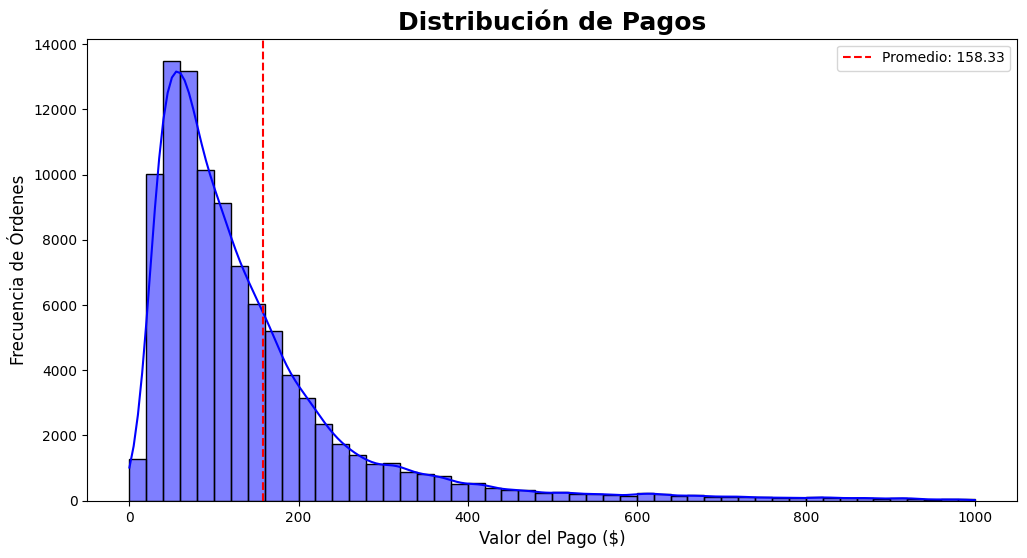

In [37]:
mean_val = df_unique_order["payment_value"].mean()

plt.figure(figsize=(12, 6))

sns.histplot(df_unique_order[df_unique_order["payment_value"] < 1000]["payment_value"], 
             color="blue", bins=50, kde=True)

plt.title("Distribución de Pagos", fontsize=18, fontweight='bold')
plt.xlabel("Valor del Pago ($)", fontsize=12)
plt.ylabel("Frecuencia de Órdenes", fontsize=12)

plt.axvline(mean_val, color='red', linestyle='--', label=f'Promedio: {mean_val:.2f}')
plt.legend()


##### Observaciones:
> -  `payment_value`: Muestra el precio de las órdenes realizadas. El precio que más se repite es el 77.57, seguido de 50.00. El valor más alto de una compra realizada es de 13664.08, seguido de 7274.88.
> - Se muestran órdenes cuyo valor es 0, esto se debe a que la orden pudo ser pagada con cupones y no se aportó dinero del cliente.
> -  La gráfica muestra una distribución unimodal  de sesgo positivo con la moda en el valor de 77, es el precio que más se repite en las órdenes. La mayoría de las ventas se concentran por debajo de los 200 La frecuencia decrece de forma exponencial a medida que aumenta el precio de la orden.


## Análisis de variables multivariante

### Númerica - Númerica

In [44]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  str    
 1   customer_id                    118434 non-null  str    
 2   order_purchase_timestamp       118434 non-null  str    
 3   customer_unique_id             118434 non-null  str    
 4   order_item_id                  117604 non-null  float64
 5   product_category_name_english  115881 non-null  str    
 6   payment_value                  118431 non-null  float64
dtypes: float64(2), str(5)
memory usage: 6.3 MB


In [ ]:
corr_price = df_master[["order_item_id", "payment_value"]].corr()

fig, axis = plt.subplots(2, 1, figsize=)

<Axes: xlabel='order_purchase_timestamp', ylabel='payment_value'>

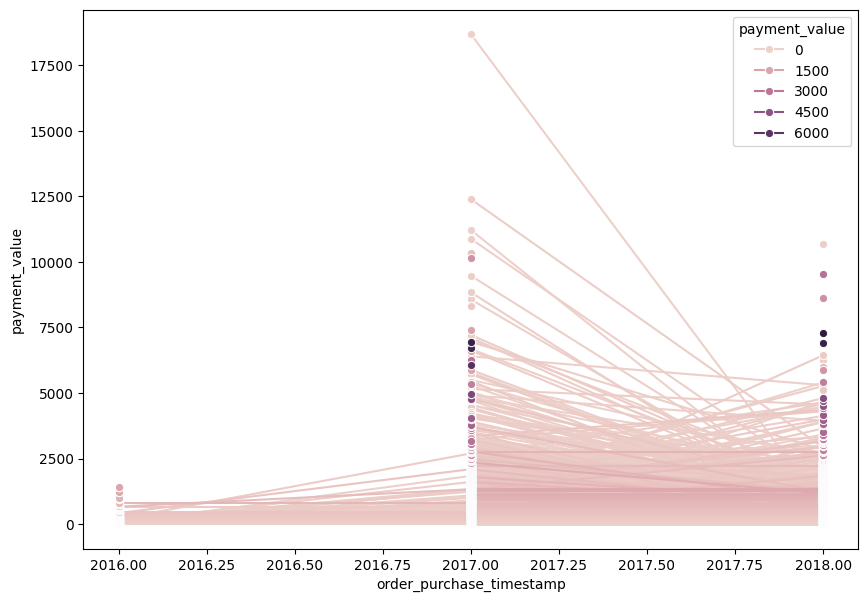

In [ ]:
# df_filtrado = df_unique_order.loc[df_unique_order["payment_value"]< 10000]
# df_filtrado["order_purchase_timestamp"] = pd.to_datetime(df_filtrado["order_purchase_timestamp"])

# plt.figure(figsize=(10, 7))
# sns.lineplot(data=df_filtrado, x=df_filtrado["order_purchase_timestamp"].dt.year, 
#              y="payment_value",                               # Variante 2: Monto
#     hue='payment_value',                               # Variante 3: Método de Pago
#     estimator='sum',                                  # Agregamos para ver el total anual
#     errorbar=None,
#     marker='o')